# Results Analysis — Cop (police) Agent (M5-7)

Analysis of the strategy track's committed instruments: the arena round-robin and champion gate,
the CI-blocking DoD win-rate floor, the M5-4 genetic-tuning run, and a weight-sensitivity sweep
around the deployed vector. **Every number regenerates from committed config**
(`config/arena.json`, `config/ga.json`, `config/ga_weights.json`) — nothing is hand-entered.

**Metric conventions.** Belief error against ground truth is $e_t = 1 - P_t(c^*)$, where
$P_t(c^*)$ is the tracking belief's mass on the opponent's true cell at step $t$ (the M3-3
identity; referee mode only — live play never sees $c^*$). GA fitness is the candidate's
win-rate for its role over a fresh scenario-seed suite,
$f(\theta) = \frac{1}{|S|} \sum_{s \in S} \mathbb{1}[\text{win}_s(\theta)]$,
with $S$ disjoint from the DoD seeds (the gate is never a training target).

**Sources.**
[1] Y. Segal, *Distributed Cops-and-Robbers over a P2P Network*, v3.0.0 — ch. 6 (strategy
module), §6.3.1 (the "your own heuristic algorithm" track). \
[2] `docs/adr/0005-strategy-track.md` — belief+search over RL (decision record). \
[3] `docs/adr/0002-reference-reuse.md` — HW6 genetic-algorithm salvage attribution. \
[4] `docs/PRD_police_brain.md` §2–§4 / `docs/PRD_thief_brain.md` §2–§3 — DoD definition,
scenario suite, perception-held-fixed disclosure.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

from copthief_core.domain.rules import Outcome
from copthief_core.sdk.arena import champion_regression, load_champions, run_round_robin
from copthief_core.sdk.arena_config import load_arena_config
from copthief_core.sdk.simulation import SimulationSdk
from copthief_core.strategy.scenarios import scenario_suite

ROOT = Path.cwd() if (Path.cwd() / "config").is_dir() else Path.cwd().parent
sdk = SimulationSdk(ROOT / "config")
arena = load_arena_config(ROOT / "config" / "arena.json")
ga = json.loads((ROOT / "config" / "ga_weights.json").read_text(encoding="utf-8"))
print("arena seeds:", list(arena.seeds), "| GA role:", ga["role"], "vs", ga["opponent"])

arena seeds: [1, 2, 3, 4, 5, 6, 7, 8] | GA role: police vs ref-thief


## Arena round-robin — per-role standings and the champion gate

Per-role rosters (a role brain only ever enters its own side, PRD_police_brain §4) over the
committed seeded scenario suite; the champion pin is the CI regression gate (CLAUDE.md §5).

In [2]:
report = run_round_robin(sdk, config=arena)
print(f"{'brain':<20}{'role':<9}{'games':>6}{'wins':>6}{'points':>8}")
print("-" * 49)
for s in report.standings:
    print(f"{s.brain:<20}{s.role:<9}{s.games:>6}{s.wins:>6}{s.points:>8}")
problems = champion_regression(report, load_champions(ROOT / "config" / "arena_champion.json"))
print()
print("champion gate:", problems if problems else "GREEN")

brain               role      games  wins  points
-------------------------------------------------
police-brain        police       24    24     480
ref-police          police       24    14     330
greedy-manhattan    police       24     8     240
random              police       24     3     165
greedy-manhattan    thief        32    21     265
ref-thief           thief        32    20     260
random              thief        32     6     190

champion gate: GREEN


## DoD win-rate floor (CI-blocking)

The configured head-to-head series against the re-derived reference heuristic — the same series
`tests/integration/test_arena_dod.py` runs as a permanent gate.

In [3]:
for dod in arena.dod_series:
    scenarios = scenario_suite(
        sdk.constitution, seeds=dod.seeds, min_separation=arena.scenario_min_separation
    )
    results = sdk.scenario_series(
        police=arena.spec_for(dod.police),
        thief=arena.spec_for(dod.thief),
        scenarios=scenarios,
        police_options=arena.options_for(dod.police),
        thief_options=arena.options_for(dod.thief),
    )
    winning = Outcome.COP_CAPTURE if dod.wins_role == "police" else Outcome.THIEF_SURVIVAL
    wins = sum(r.outcome is winning for r in results)
    rate = wins / len(results)
    verdict = "PASS" if rate >= dod.min_win_rate else "FAIL"
    print(
        f"{dod.label}\n  {wins}/{len(results)} = {rate:.1%} (floor {dod.min_win_rate:.0%}) -> {verdict}"
    )

M5-2 police DoD - PoliceBrain vs the reference heuristic
  30/32 = 93.8% (floor 60%) -> PASS


## Genetic-tuning fitness curve (M5-4)

The committed offline run (`config/ga_weights.json`, written by `scripts/ga_run.py`): elitism
makes the best curve non-decreasing by construction; the dotted line is the default (untuned)
weight vector's fitness on the same suite.

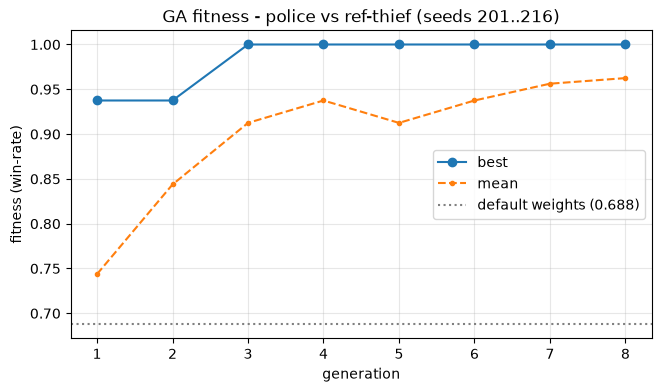

default 0.688 -> evolved 1.000


In [4]:
history = ga["history"]
generations = list(range(1, len(history) + 1))
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(generations, [g["best"] for g in history], marker="o", label="best")
ax.plot(generations, [g["mean"] for g in history], marker=".", linestyle="--", label="mean")
ax.axhline(
    ga["default_fitness"],
    color="grey",
    linestyle=":",
    label=f"default weights ({ga['default_fitness']:.3f})",
)
ax.set_xlabel("generation")
ax.set_ylabel("fitness (win-rate)")
ax.set_title(
    f"GA fitness - {ga['role']} vs {ga['opponent']} "
    f"(seeds {ga['fitness_seeds'][0]}..{ga['fitness_seeds'][-1]})"
)
ax.legend()
ax.grid(alpha=0.3)
plt.show()
print(f"default {ga['default_fitness']:.3f} -> evolved {ga['evolved_fitness']:.3f}")

## Weight sensitivity around the deployed vector

One gene at a time, swept across its GA search box while every other deployed weight holds; the
response is the DoD win-rate on the committed gate suite. The dotted vertical line marks the
deployed value. Flat regions mean the gene box is forgiving; cliffs mark load-bearing weights.

w_distance = 0.500 -> DoD 62.5%
w_distance = 1.875 -> DoD 75.0%
w_distance = 3.250 -> DoD 87.5%
w_distance = 4.625 -> DoD 93.8%
w_distance = 6.000 -> DoD 93.8%


p_commit = 0.200 -> DoD 93.8%
p_commit = 0.350 -> DoD 96.9%
p_commit = 0.500 -> DoD 96.9%
p_commit = 0.650 -> DoD 96.9%
p_commit = 0.800 -> DoD 96.9%


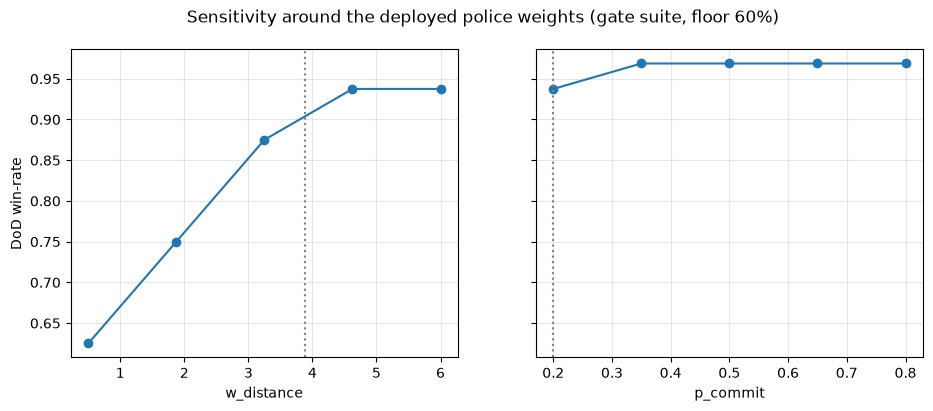

In [5]:
ga_config = json.loads((ROOT / "config" / "ga.json").read_text(encoding="utf-8"))
dod = arena.dod_series[0]
scenarios = scenario_suite(
    sdk.constitution, seeds=dod.seeds, min_separation=arena.scenario_min_separation
)
mine = ga["role"]
my_name = dod.police if mine == "police" else dod.thief
their_name = dod.thief if mine == "police" else dod.police
winning = Outcome.COP_CAPTURE if mine == "police" else Outcome.THIEF_SURVIVAL
base_options = arena.options_for(my_name)
sweep_genes = ["w_distance", "p_commit"]
POINTS = 5
fig, axes = plt.subplots(1, len(sweep_genes), figsize=(11, 4), sharey=True)
for ax, gene in zip(axes, sweep_genes, strict=True):
    low, high = ga_config["genes"][gene]
    values = [low + i * (high - low) / (POINTS - 1) for i in range(POINTS)]
    rates = []
    for value in values:
        options = {**base_options, gene: value}
        results = sdk.scenario_series(
            police=arena.spec_for(dod.police),
            thief=arena.spec_for(dod.thief),
            scenarios=scenarios,
            police_options=options if mine == "police" else arena.options_for(their_name),
            thief_options=arena.options_for(their_name) if mine == "police" else options,
        )
        rates.append(sum(r.outcome is winning for r in results) / len(results))
    ax.plot(values, rates, marker="o")
    if gene in base_options:
        ax.axvline(base_options[gene], color="grey", linestyle=":")
    ax.set_xlabel(gene)
    ax.grid(alpha=0.3)
    for value, rate in zip(values, rates, strict=True):
        print(f"{gene} = {value:.3f} -> DoD {rate:.1%}")
axes[0].set_ylabel("DoD win-rate")
fig.suptitle(
    f"Sensitivity around the deployed {mine} weights (gate suite, floor {dod.min_win_rate:.0%})"
)
plt.show()

## Reading the results

- The **arena** shows the tuned `police-brain` clear of every baseline in its role table with the
  champion gate green; the **DoD floor** holds with the deployed evolved weights (the same series
  is a permanent CI gate, so this table cannot drift from the tree).
- The **GA curve** improves and validates off-suite (PR #35: DoD 75%→94%, holdout 78%→97%) —
  detail and honesty notes in `docs/evidence/m5-ga.md` and the PR record.
- The **sensitivity sweep** contextualizes the deployed vector: where the response is flat the
  exact value is not load-bearing; cliffs justify the GA's choice. The M5-6 deception A/B is
  thief-led — its measured table lives in the sibling repo's notebook and evidence
  ([copthief-p2p-thief](https://github.com/Imreec/copthief-p2p-thief)).